# Estadística para Minería de Datos

**Universidad de los Andes — Minería de Datos**  
**Semana 1 — Preprocesamiento de Datos**

---

## Objetivos de aprendizaje

- Comprender los conceptos fundamentales de la estadística descriptiva aplicada a la minería de datos.
- Calcular e interpretar medidas de tendencia central, dispersión y frecuencia sobre conjuntos de datos reales.
- Aplicar medidas de covarianza, correlación y distancia para analizar relaciones entre variables.
- Utilizar medidas de similitud para comparar conjuntos de datos en tareas de clustering y recomendación.

## 1. Introducción a la Estadística

La **estadística** es la disciplina que se ocupa de la recopilación, organización, análisis, interpretación y presentación de datos.

Existen tres aspectos principales en los que la estadística se aplica:

- **Describir:** El mundo es complejo y a menudo se necesita describirlo de una manera simplificada. La estadística proporciona las herramientas para resumir y visualizar grandes cantidades de datos, con el fin de captar patrones y tendencias importantes.

- **Decidir:** En muchas ocasiones, se deben tomar decisiones basadas en datos, generalmente en condiciones de incertidumbre. La estadística ofrece métodos para evaluar opciones y tomar decisiones informadas, minimizando riesgos y maximizando beneficios.

- **Predecir:** A menudo se desea hacer predicciones sobre nuevas situaciones basadas en conocimiento de situaciones anteriores. La estadística ayuda a construir modelos que pueden prever comportamientos futuros, basados en datos históricos.

Esta sección del notebook esta enfocada en la **estadística descriptiva**, que es la rama de la estadística encargada de describir y resumir la información contenida en los datos, sin hacer inferencias sobre la población en general. Esta es una parte fundamental del Análisis Exploratorio de Datos (EDA).


## 2. Atributos y Frecuencias

El cálculo de estadísticas básicas es fundamental en el análisis exploratorio de datos (EDA) para comprender el comportamiento y las características de las variables en un conjunto de datos. Este paso es crucial antes de proceder con cualquier tipo de modelado, ya que nos proporciona una visión general que puede revelar patrones, anomalías, y relaciones importantes que no son evidentes a simple vista. A continuación, profundizaremos en las principales estadísticas básicas y proporcionaremos ejemplos prácticos en Python utilizando `pandas`, `numpy` y `scikit-learn`.


**Conjunto de Datos Ejemplo**

- Se va a trabajar con un conjunto de datos muy conocido llamado **Iris**.

- El conjunto de datos consta de 150 observaciones de flores de la planta iris.

- Hay tres clases de flores de iris: **virginica**,   **setosa** y **versicolor**.

- Hay 50 observaciones de cada una.

- Las variables o atributos medidos para cada flor son:

![](images/Petal-sepal.jpg)

![](https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/01_iris.jpeg)

![](https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/01_terminology.png)
![](https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/01_iris3d.png)

---

**Atributos**

El análisis de atributos se centra en examinar las características individuales de cada variable en el conjunto de datos. Esto incluye determinar el tipo de dato (categórico o numérico), identificar el rango de valores, y analizar su distribución.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Cargar el dataset Iris
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [ ]:
# Análisis de atributos
print("Tipos de datos por columna:")
print(df.dtypes)

print("\nValores únicos por columna:")
print(df.nunique())

Tipos de datos por columna:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

Valores únicos por columna:
sepal length (cm)    35
sepal width (cm)     23
petal length (cm)    43
petal width (cm)     22
dtype: int64


### 2.1 Frecuencia Absoluta y Relativa

Las medidas de **frecuencia** son fundamentales en estadística descriptiva para entender la distribución de datos categóricos.

- **Frecuencia Absoluta**: Es el conteo del número de veces que ocurre un valor en un conjunto de datos.

  Sea \( n \) el tamaño total de la muestra, y \( x_i \) una categoría específica dentro de la variable. La frecuencia absoluta \( f_i \) se define como:

  $$
  f_i = \text{Número de observaciones de } x_i
  $$

- **Frecuencia Relativa**: Es la proporción o porcentaje del número de veces que ocurre un valor en un conjunto de datos, en relación con el tamaño total de la muestra.

  La frecuencia relativa \( r_i \) se define como:

  $$
  r_i = \frac{f_i}{n}
  $$

  donde \( f_i \) es la frecuencia absoluta de la categoría \( x_i \) y \( n \) es el tamaño total de la muestra.


In [ ]:
df2 = df
df2['species'] = data.target

# Calcular la frecuencia absoluta de cada especie
absolute_frequency = df2['species'].value_counts()
print("Frecuencia Absoluta:")
print(absolute_frequency)

# Calcular la frecuencia relativa de cada especie
relative_frequency = df2['species'].value_counts(normalize=True)
print("Frecuencia Relativa:")
print(relative_frequency)

Frecuencia Absoluta:
species
0    50
1    50
2    50
Name: count, dtype: int64
Frecuencia Relativa:
species
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


## 3. Medidas de Tendencia Central


Las medidas de tendencia central son valores que representan el "centro" de una distribución de datos. Las más comunes son: 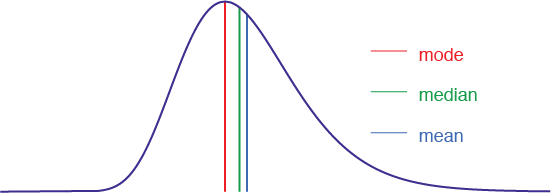




- **Media (Mean):** El promedio de todos los valores. Se calcula sumando todos los valores y dividiendo por el número total de observaciones.

  $$
  \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
  $$

  Donde:
  - \(n\) es el número total de observaciones.
  - \(x_i\) es el valor de la \(i\)-ésima observación.

- **Mediana (Median):** El valor central que divide la distribución en dos partes iguales. Si el número de observaciones es impar, la mediana es el valor central. Si es par, es el promedio de los dos valores centrales.

  Para una distribución ordenada:

  - Si \(n\) es impar, la mediana es
  
  $$
  \text{Mediana} = x_{\left(\frac{n+1}{2}\right)}
  $$
  
  - Si \(n\) es par, la mediana es:

  $$
  \text{Mediana} = \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2} + 1\right)}}{2}
  $$

- **Moda (Mode):** El valor que aparece con mayor frecuencia en el conjunto de datos.

  La moda es simplemente el valor \(x_m\) que maximiza la frecuencia en la distribución de los datos:

  $$
  x_m = \text{argmax}_{x}(f(x))
  $$

Donde \(f(x)\) es la función de frecuencia de los datos.

Las medidas de tendencia central son fundamentales para resumir el "centro" de un conjunto de datos, y cada una de ellas proporciona una perspectiva diferente sobre el comportamiento central de los datos.


In [ ]:
# Cálculo de la media, mediana y moda
mean_value = df['sepal length (cm)'].mean()
median_value = df['sepal length (cm)'].median()
mode_value = df['sepal length (cm)'].mode()[0]

print(f"Media de 'sepal length (cm)': {mean_value}")
print(f"Mediana de 'sepal length (cm)': {median_value}")
print(f"Moda de 'sepal length (cm)': {mode_value}")


Media de 'sepal length (cm)': 5.843333333333334
Mediana de 'sepal length (cm)': 5.8
Moda de 'sepal length (cm)': 5.0


## 4. Medidas de Dispersión

Las medidas de dispersión permiten entender cómo varían los datos en un conjunto dado. Estas medidas indican qué tan dispersos o concentrados están los valores alrededor de una medida de tendencia central.

### 4.1 Varianza

Mide la dispersión de los datos respecto a la media. Se calcula como el promedio de las diferencias al cuadrado entre cada valor y la media. La fórmula para la varianza de una población es:

$$
\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2
$$

Para una muestra, la varianza se calcula de la siguiente manera:

$$
s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2
$$

Donde:
- \(N\) es el número de datos en la población.
- \(n\) es el número de datos en la muestra.
- \(x_i\) es cada valor individual.
- \(\mu\) es la media de la población.
- \(\bar{x}\) es la media de la muestra.

### 4.2 Desviación Estándar

Es la raíz cuadrada de la varianza. Es una medida que indica en promedio cuánto se desvían los valores respecto a la media.

Para una población, se calcula como:

$$
\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}
$$

Para una muestra, se calcula como:

$$
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

### 4.3 Rango

Es la diferencia entre el valor máximo y el valor mínimo en un conjunto de datos:

$$
Rango = \text{Valor Máximo} - \text{Valor Mínimo}
$$

### 4.4 Percentiles

Indican la posición de un valor en relación con el resto de los datos. El percentil \(k\)-ésimo es el valor por debajo del cual se encuentra el \(k\%\) de los datos:

$$
\text{Percentil}_k = P(X < x_k) = k\%
$$

In [ ]:
# Cálculo de la desviación estándar, varianza, rango y percentiles
std_dev = df['sepal length (cm)'].std()
variance = df['sepal length (cm)'].var()
rango = df['sepal length (cm)'].max() - df['sepal length (cm)'].min()
percentiles = df['sepal length (cm)'].quantile([0.25, 0.5, 0.75])

print(f"Desviación estándar de 'sepal length (cm)': {std_dev}")
print(f"Varianza de 'sepal length (cm)': {variance}")
print(f"Rango de 'sepal length (cm)': {rango}")
print(f"Percentiles (25%, 50%, 75%) de 'sepal length (cm)':\n{percentiles}")


Desviación estándar de 'sepal length (cm)': 0.828066127977863
Varianza de 'sepal length (cm)': 0.6856935123042507
Rango de 'sepal length (cm)': 3.6000000000000005
Percentiles (25%, 50%, 75%) de 'sepal length (cm)':
0.25    5.1
0.50    5.8
0.75    6.4
Name: sepal length (cm), dtype: float64


In [ ]:
# El metodo describe de pandas permite obtener un resumen de las medidas de tendencia central y dispersion de todo el DataFrame
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


En el describe, se encuentra incluida la variable species que es categorica, estos valores obtenidos no tienen ningun valor dado que este analisis es solo para variables numericas. En el caso que se quiera utilizar primero se debe hacer un transformación de la variables


## 5. Covarianza

Mide la relación entre dos variables, indicando si aumentan o disminuyen juntas. Una covarianza positiva sugiere que las variables tienden a aumentar juntas, mientras que una covarianza negativa indica una relación inversa.

La covarianza entre dos variables \(X\) e \(Y\) se calcula usando la siguiente fórmula:

$$\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} \left( X_i - \bar{X} \right) \left( Y_i - \bar{Y} \right)$$

Donde:
- \(X_i\) e \(Y_i\) son los valores individuales de las variables \(X\) e \(Y\).
- \(\bar{X}\) y \(\bar{Y}\) son las medias de \(X\) e \(Y\).
- \(n\) es el número de observaciones.


In [ ]:
# Cálculo de la covarianza entre 'sepal length (cm)' y 'petal length (cm)'
covariance = df['sepal length (cm)'].cov(df['petal length (cm)'])

print(f"Covarianza entre 'sepal length (cm)' y 'petal length (cm)': {covariance}")


Covarianza entre 'sepal length (cm)' y 'petal length (cm)': 1.2743154362416111


## 6. Correlación


Cuantifica la relación lineal entre dos variables, con un valor que varía entre -1 y 1. Valores cercanos a 1 o -1 indican una relación lineal fuerte, mientras que valores cercanos a 0 indican una relación débil.

La correlación de Pearson se calcula utilizando la siguiente fórmula:

$$\rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$$

Donde:
- \(\text{Cov}(X, Y)\) es la covarianza entre \(X\) e \(Y\).
- \(\sigma_X\) y \(\sigma_Y\) son las desviaciones estándar de \(X\) e \(Y\).

In [ ]:
# Cálculo de la correlación entre 'sepal length (cm)' y 'petal length (cm)'
correlation = df['sepal length (cm)'].corr(df['petal length (cm)'])

print(f"Correlación entre 'sepal length (cm)' y 'petal length (cm)': {correlation}")


Correlación entre 'sepal length (cm)' y 'petal length (cm)': 0.8717537758865831


### 6.1 Elección de la Prueba de Correlación

Como se explicó en el notebook anterior, la elección del método de correlación depende del tipo de variable que estemos analizando:

- **Correlación de Pearson:** Este método se utiliza cuando ambas variables son numéricas y se quiere medir la relación lineal entre ellas.

- **Prueba de Chi-Cuadrado (χ²):** Cuando se trabaja con variables categóricas, la correlación lineal no es aplicable. En estos casos, se utiliza la prueba de Chi-Cuadrado para medir la asociación entre las categorías de las variables.

Por lo tanto, es crucial seleccionar el método de análisis adecuado según la naturaleza de las variables para obtener resultados precisos y significativos en el análisis de datos.

## 7. Medidas de Distancia

Las medidas de distancia son fundamentales en algoritmos de clustering y otros métodos de análisis. La distancia euclidiana y la distancia Manhattan son dos de las más comunes y cuantifican cuán alejados están dos puntos de datos en el espacio de características.

### 7.1 Distancia Euclidiana

Es la distancia "ordinaria" entre dos puntos en un espacio euclidiano. Es la longitud del segmento de línea recta que conecta los dos puntos.

La distancia euclidiana entre dos puntos \( A = (x_1, y_1) \) y \( B = (x_2, y_2) \) en un plano se calcula con la siguiente fórmula:

$$\text{Distancia Euclidiana} = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

### 7.2 Distancia de Manhattan

También conocida como distancia de bloques o L1, es la suma de las diferencias absolutas de sus coordenadas. Representa la distancia entre dos puntos si uno solo puede moverse a lo largo de ejes ortogonales (como las calles de una ciudad dispuestas en una cuadrícula).

La distancia de Manhattan entre dos puntos \( A = (x_1, y_1) \) y \( B = (x_2, y_2) \) se calcula con la siguiente fórmula:

$$\text{Distancia de Manhattan} = |x_2 - x_1| + |y_2 - y_1|
$$

In [ ]:
from scipy.spatial.distance import euclidean, cityblock

# Calcular la distancia euclidiana y Manhattan entre dos puntos
point1 = df.iloc[0][['sepal length (cm)', 'sepal width (cm)']]
point2 = df.iloc[1][['sepal length (cm)', 'sepal width (cm)']]

euclidean_distance = euclidean(point1, point2)
manhattan_distance = cityblock(point1, point2)

print(f"Distancia Euclidiana entre punto 1 y 2: {euclidean_distance}")
print(f"Distancia Manhattan entre punto 1 y 2: {manhattan_distance}")


Distancia Euclidiana entre punto 1 y 2: 0.5385164807134502
Distancia Manhattan entre punto 1 y 2: 0.6999999999999993


## 8. Medidas de Similitud

Las medidas de similitud se utilizan para evaluar cuán similares son los datos entre sí. Ejemplos incluyen el coeficiente de coseno y la distancia de Jaccard, que son fundamentales en tareas de clustering y técnicas de recomendación.

### 8.1 Similitud del Coseno

Es una medida utilizada para calcular la similitud entre dos vectores en un espacio de características, comparando la orientación de los vectores en lugar de su magnitud. Esta medida es especialmente útil cuando se trabaja con datos de texto o cuando se quiere medir la similitud entre conjuntos de datos de alta dimensionalidad.


La similitud del coseno entre dos vectores \( A \) y \( B \) se define como:

$$\text{Similitud del Coseno} = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}
$$

Donde:
- \( A \cdot B \) es el producto punto (dot product) entre los vectores \( A \) y \( B \).
- \( \|A\| \) es la norma (longitud) del vector \( A \).
- \( \|B\| \) es la norma (longitud) del vector \( B \).
- \( \theta \) es el ángulo entre los dos vectores.

La similitud del coseno varía entre -1 y 1:
- Un valor de 1 indica que los dos vectores son idénticos en orientación.
- Un valor de 0 indica que los vectores son ortogonales, es decir, no tienen similitud en cuanto a la dirección.
- Un valor de -1 indica que los vectores son diametralmente opuestos en orientación.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calcular la similitud del coseno entre dos puntos
point1 = df.iloc[0][['sepal length (cm)', 'sepal width (cm)']].values.reshape(1, -1)
point2 = df.iloc[1][['sepal length (cm)', 'sepal width (cm)']].values.reshape(1, -1)

cosine_sim = cosine_similarity(point1, point2)[0][0]

print(f"Similitud de coseno entre punto 1 y 2: {cosine_sim}")


Similitud de coseno entre punto 1 y 2: 0.9986441317408811


### 8.2 Distancia de Jaccard

 Métrica de disimilitud utilizada para comparar la diversidad de conjuntos de datos binarios. Es particularmente útil cuando se trabaja con datos categóricos o binarios, como en el caso de la clasificación de documentos, análisis de similitud en conjuntos de datos, entre otros.


El **Índice de Jaccard** mide la similitud entre dos conjuntos y se define como el tamaño de la intersección dividido por el tamaño de la unión de los conjuntos:

$$
\text{Índice de Jaccard} = \frac{|A \cap B|}{|A \cup B|}
$$

Donde:
- $A \cap B$ es el tamaño de la intersección de los conjuntos \( A \) y \( B \).
- $A \cup B $ es el tamaño de la unión de los conjuntos \( A \) y \( B \).


La **Distancia de Jaccard** es la medida de disimilitud derivada del índice de Jaccard, y se calcula como:

$$
\text{Distancia de Jaccard} = 1 - \text{Índice de Jaccard}
$$




In [ ]:
from sklearn.metrics import jaccard_score

# Crear dos conjuntos binarios de ejemplo
set1 = [1, 1, 0, 0, 1, 0, 0, 1, 0, 1]
set2 = [0, 1, 1, 0, 1, 0, 1, 0, 0, 1]

# Calcular la distancia de Jaccard
jaccard_distance = 1 - jaccard_score(set1, set2)

print(f"Distancia de Jaccard entre los dos conjuntos: {jaccard_distance}")

Distancia de Jaccard entre los dos conjuntos: 0.5714285714285714


## Referencias

**Texto guía**
- Notas de clase del curso (disponibles en el repositorio).

**Bibliografía complementaria**
- Montgomery, D. C., & Runger, G. C. (2018). *Applied Statistics and Probability for Engineers* (7th ed.). Wiley.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python* (Cap. 2). Springer.
- Tan, P. N., Steinbach, M., Karpatne, A., & Kumar, V. (2019). *Introduction to Data Mining* (2nd ed., Cap. 2). Pearson.